# End-to-end Data Engineering with DuckDB & Python

This is a 'do it along' following [DuckDB](https://motherduck.com/blog/duckdb-python-e2e-data-engineering-project-part-1/) material. We will source data from [PyPi](https://pypi.org/), a repository of python packages providing logs of how given libraries have been used across platforms, transform it  into relevant tables, and feed it into a dashboard using SQL, [dtb](https://www.getdbt.com/) - a tool for building modular, maintainable data pipelines to power analytics, and [DuckDB](https://duckdb.org/) - an in-process SQL online analytical processing (OLAPs) relational database management system; then use [evidence](https://evidence.dev/) to create a dashboard utilizing SQL and markdown.

## Part 1: Ingestion pipeline 

### Setup & requirements

- Python 3.12
- [Poetry](https://python-poetry.org/) for dependency management
- [Make](https://www.gnu.org/software/make/manual/make.html) to run Makefile commands
- [A Google Cloud account](https://cloud.google.com/?hl=en) to fetch the source data. Free tier covers any computing cost.
- A host of libraries: `poetry` `duckdb` `google-cloud-bigquery` `google-auth` `google-cloud-bigquery-storage`
`pyarrow` `pandas` `fire` l`oguru` `pydantic` `pytest` `ruff`

The architecture woul look like below

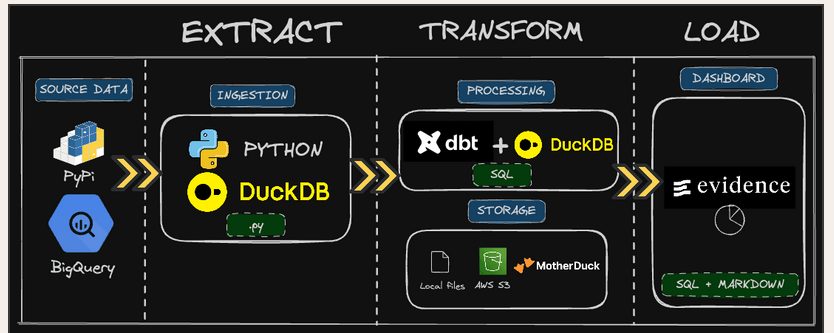

In [2]:
from PIL import Image
from IPython.display import display

img_f = "./docs/architecture.png"
img = Image.open(img_f)
display(img)



## Exploring the data

Head to your google cloud console, then under BigQuery search "file_downloads" and click `SEARCH ALL PROJECTS`. 

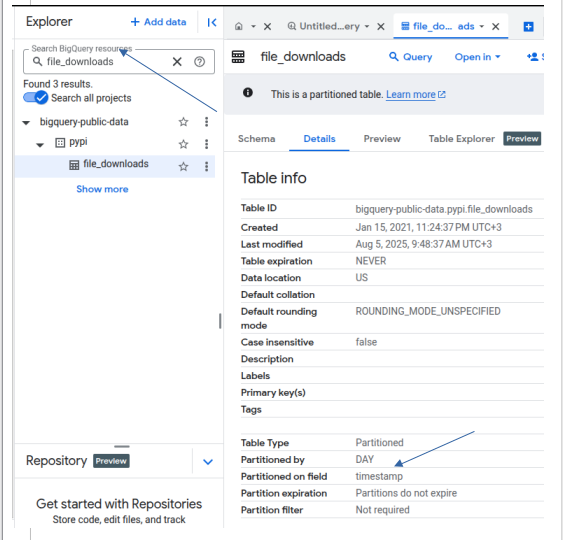

In [3]:
img_f = "./docs/big_query_search.png"
img = Image.open(img_f)
display(img)

Limit your query to a given timestamp as the data is very big.

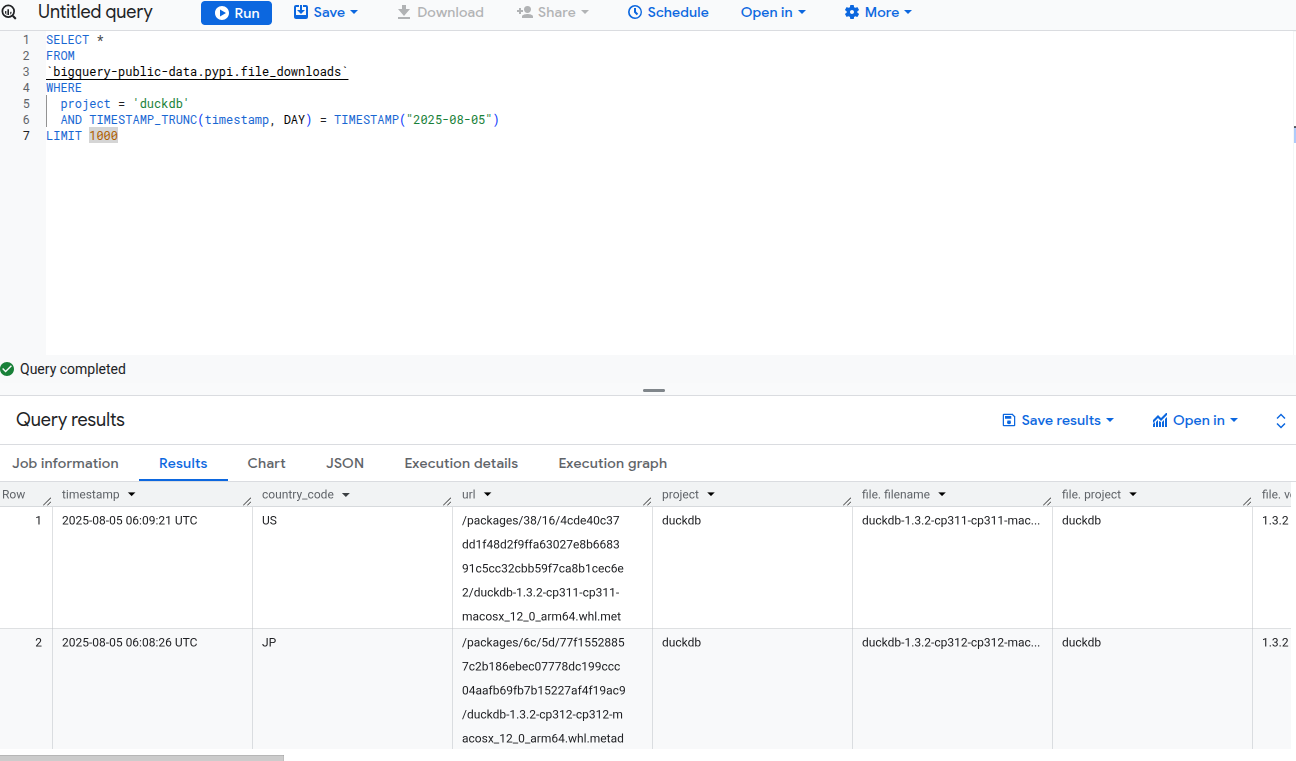

In [4]:
img_f = "./docs/query.png"
img = Image.open(img_f)
display(img)

The ingestion part is bundled in `/ingestion` directory with the following primary files:

In [5]:
!tree ./ingestion

./ingestion
├── bigquery.py
├── duck.py
├── models.py
├── pipeline.py
└── __pycache__
    ├── bigquery.cpython-312.pyc
    └── pipeline.cpython-312.pyc

2 directories, 6 files


- `bigquery.py` has BigQuery helpers to get the client, get query results and query the public dataset
- `duck.py` contains DuckDB helpers to create a table from a dataframe, and write to a local or MotherDuck database
- `models.py` defines table schema
- `pipeline` runs the ingestion pipeline use `pydantic` syntax

The pipeline was successfuly executed and data written locally and to motherduck:

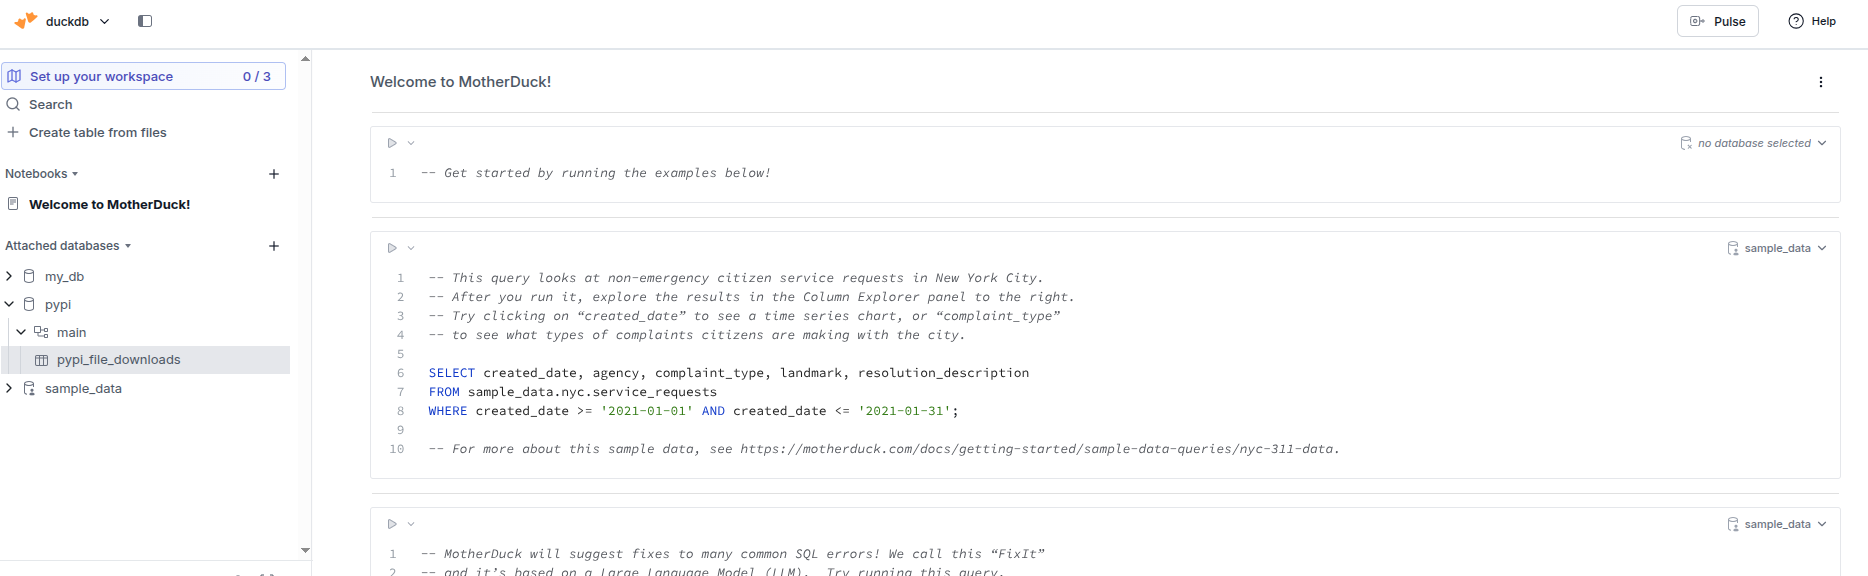

In [6]:
img_f = "./docs/motherduck_db.png"
img = Image.open(img_f)
display(img)